# Visualisations

Charts for the Pizza Sales analysis. Every figure is built from a query against
`pizza_sales.db` - run [main.ipynb](main.ipynb) first to create it.

Nothing here is hard-coded: change the data or a query and the charts follow.

## Setup

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

DB_PATH = Path("pizza_sales.db")
IMAGE_DIR = Path("image")
IMAGE_DIR.mkdir(exist_ok=True)

if not DB_PATH.exists():
    raise FileNotFoundError(f"{DB_PATH} not found - run main.ipynb first")

con = sqlite3.connect(DB_PATH)

def run(sql: str) -> pd.DataFrame:
    return pd.read_sql_query(sql, con)

## A Single Chart Helper

All twelve charts are the same bar chart with different labels, so they share one function
rather than twelve copies of the same forty lines.

In [2]:
BAR_COLOR = "steelblue"
AVG_COLOR = "firebrick"


def bar_chart(data, x, y, title, ylabel, filename, money=False, show_avg=True,
              rotate=0, xlabel=None):
    """Draw a labelled bar chart with an average line and save it to image/."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(data[x], data[y], color=BAR_COLOR)

    fmt = (lambda v: f"${v:,.0f}") if money else (lambda v: f"{v:,.0f}")

    if show_avg:
        avg = data[y].mean()
        ax.axhline(avg, color=AVG_COLOR, linestyle="--", linewidth=1.5,
                   label=f"Average: {fmt(avg)}")
        ax.legend()

    for i, value in enumerate(data[y]):
        # White backing keeps the label readable where it crosses the average line.
        ax.text(i, value, fmt(value), ha="center", va="bottom", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                          edgecolor="none", alpha=0.75))

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel or x.replace("_", " ").title())
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.margins(y=0.12)
    if money:
        ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
    if rotate:
        plt.setp(ax.get_xticklabels(), rotation=rotate, ha="right")

    fig.tight_layout()
    fig.savefig(IMAGE_DIR / filename, dpi=110)
    plt.show()

## Sales by Hour of the Day

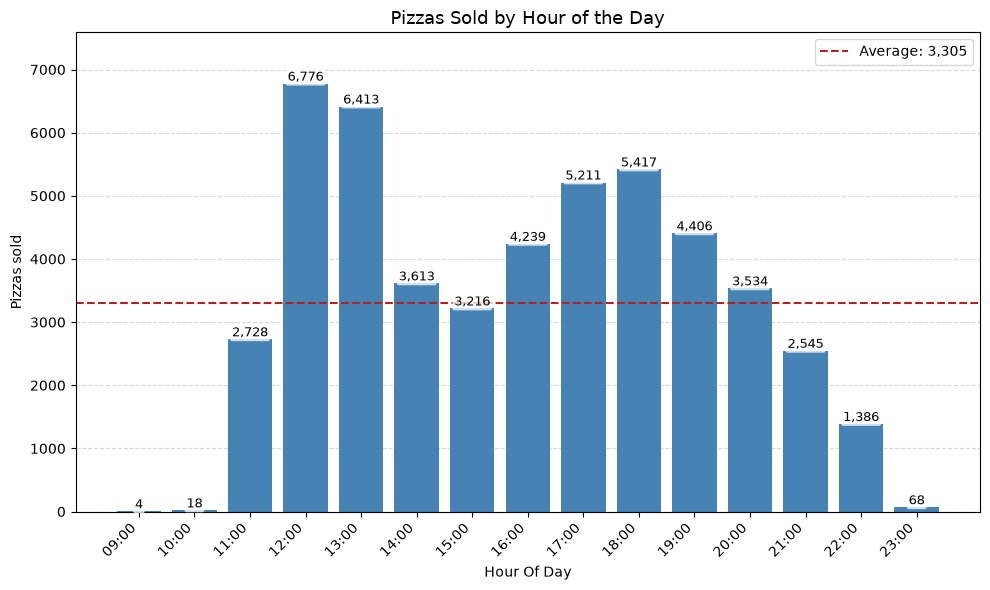

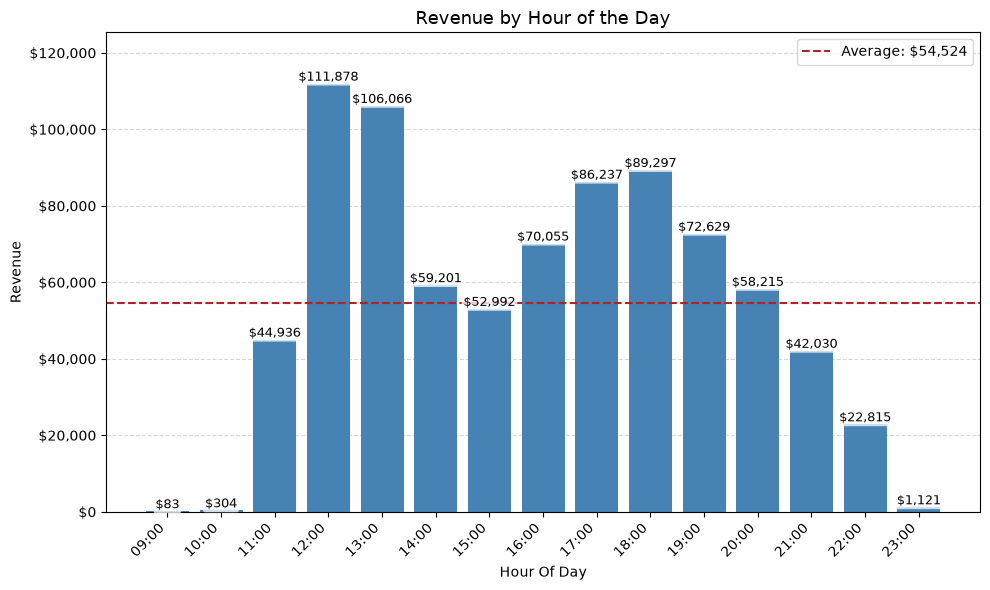

In [3]:
hourly = run("""
SELECT strftime('%H:00', o.order_time)           AS hour_of_day,
       SUM(od.quantity)                          AS total_quantity,
       ROUND(SUM(od.quantity * p.unit_price), 2) AS total_revenue
FROM orders AS o
JOIN order_details AS od ON od.order_id = o.order_id
JOIN pizzas        AS p  ON p.pizza_id  = od.pizza_id
GROUP BY hour_of_day
ORDER BY hour_of_day;
""")

bar_chart(hourly, "hour_of_day", "total_quantity",
          "Pizzas Sold by Hour of the Day", "Pizzas sold",
          "hourly_quantity.png", rotate=45)

bar_chart(hourly, "hour_of_day", "total_revenue",
          "Revenue by Hour of the Day", "Revenue",
          "hourly_revenue.png", money=True, rotate=45)

## Sales by Day of the Week

The third chart is the one to trust. Seven days do not get an equal number of shifts in this
dataset - four Mondays in October are missing entirely - so total revenue understates Monday.
Dividing by the number of days the shop actually traded removes that bias.

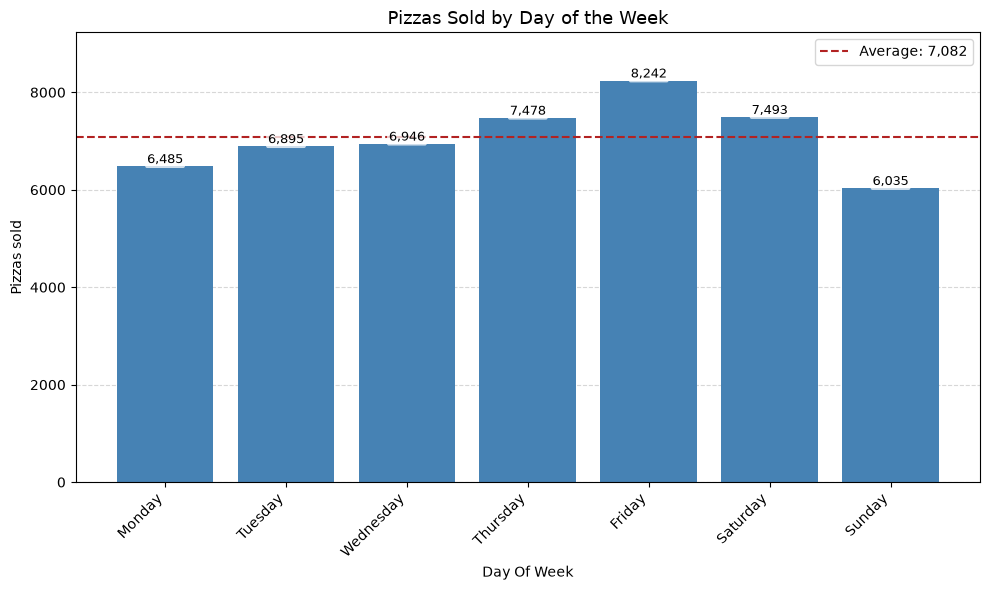

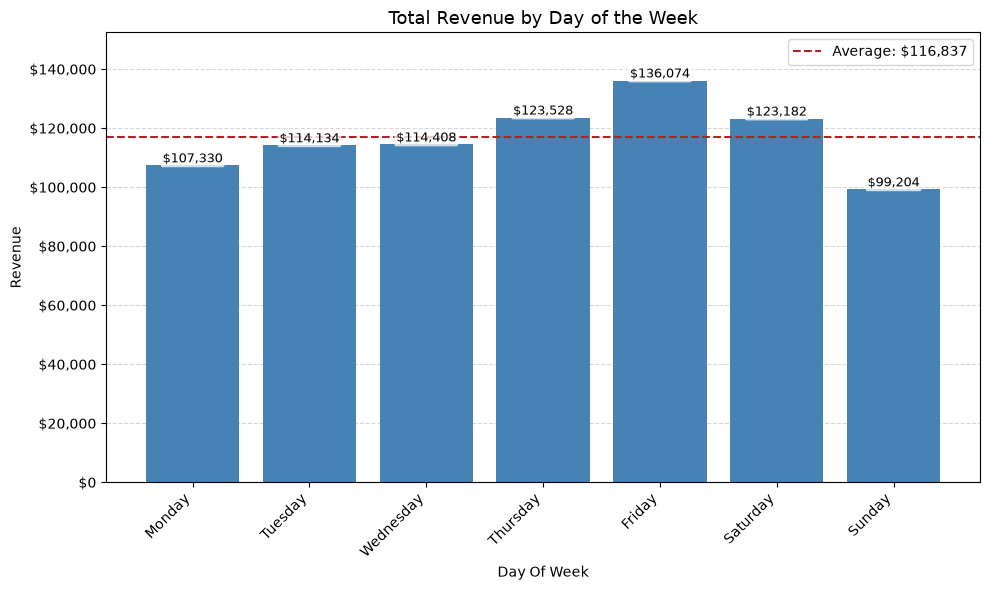

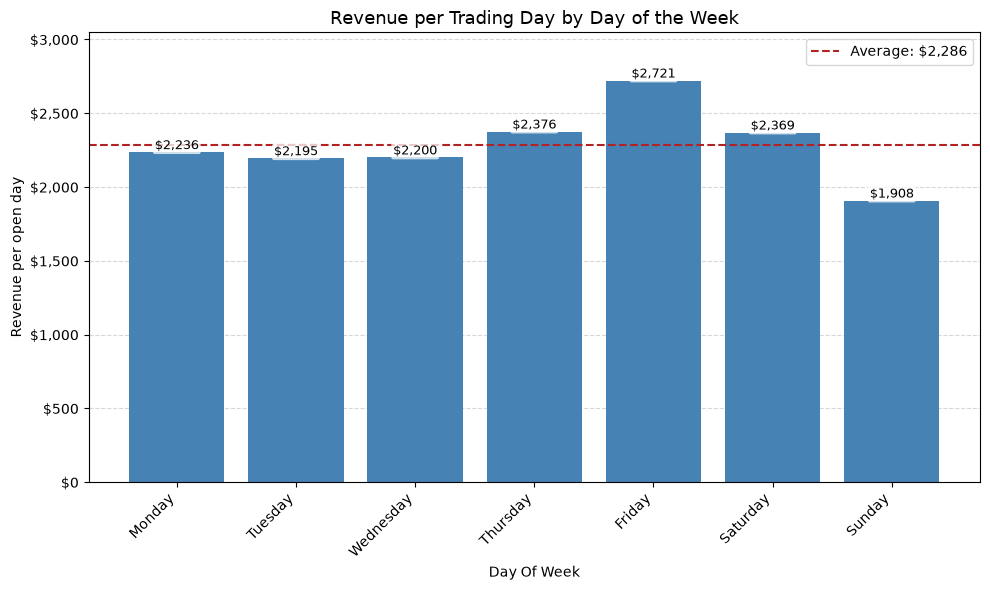

,day_of_week,operating_days,total_revenue,revenue_per_day
0,Monday,48,107329.55,2236.03
1,Tuesday,52,114133.80,2194.88
2,Wednesday,52,114408.40,2200.16
3,Thursday,52,123528.50,2375.55
4,Friday,50,136073.90,2721.48
5,Saturday,52,123182.40,2368.89
6,Sunday,52,99203.50,1907.76


In [4]:
weekday = run("""
SELECT CASE strftime('%w', o.order_date)
           WHEN '0' THEN 'Sunday'   WHEN '1' THEN 'Monday'
           WHEN '2' THEN 'Tuesday'  WHEN '3' THEN 'Wednesday'
           WHEN '4' THEN 'Thursday' WHEN '5' THEN 'Friday'
           ELSE 'Saturday'
       END                                        AS day_of_week,
       CAST(strftime('%w', o.order_date) AS INT)  AS day_number,
       COUNT(DISTINCT o.order_date)               AS operating_days,
       SUM(od.quantity)                           AS total_quantity,
       ROUND(SUM(od.quantity * p.unit_price), 2)  AS total_revenue,
       ROUND(SUM(od.quantity * p.unit_price)
             / COUNT(DISTINCT o.order_date), 2)   AS revenue_per_day
FROM orders AS o
JOIN order_details AS od ON od.order_id = o.order_id
JOIN pizzas        AS p  ON p.pizza_id  = od.pizza_id
GROUP BY day_of_week
ORDER BY CASE day_number WHEN 0 THEN 7 ELSE day_number END;
""")

bar_chart(weekday, "day_of_week", "total_quantity",
          "Pizzas Sold by Day of the Week", "Pizzas sold",
          "weekly_quantity.png", rotate=45)

bar_chart(weekday, "day_of_week", "total_revenue",
          "Total Revenue by Day of the Week", "Revenue",
          "weekly_revenue.png", money=True, rotate=45)

bar_chart(weekday, "day_of_week", "revenue_per_day",
          "Revenue per Trading Day by Day of the Week", "Revenue per open day",
          "weekly_revenue_per_day.png", money=True, rotate=45)

weekday[["day_of_week", "operating_days", "total_revenue", "revenue_per_day"]]

## Sales by Month

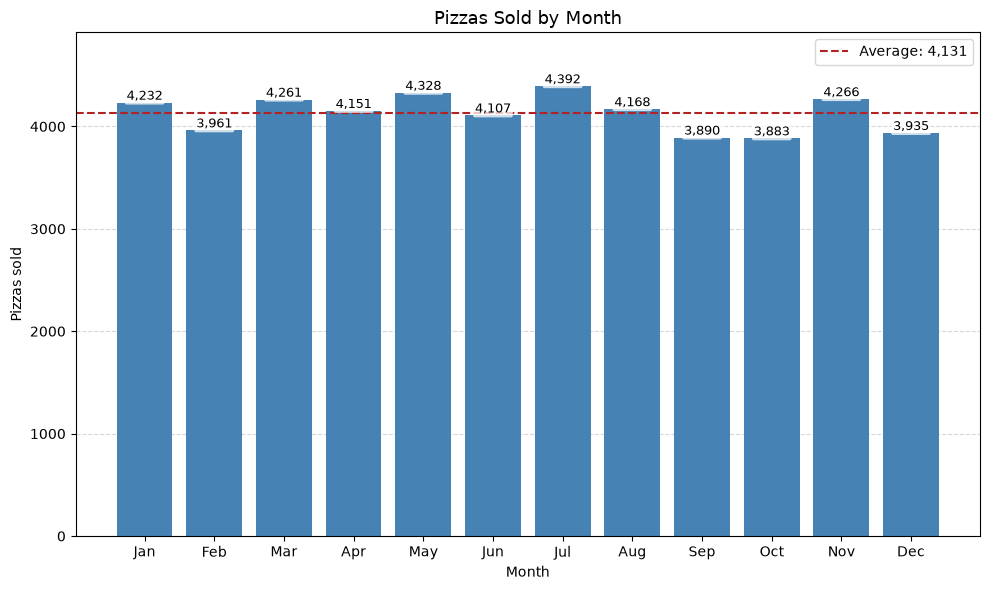

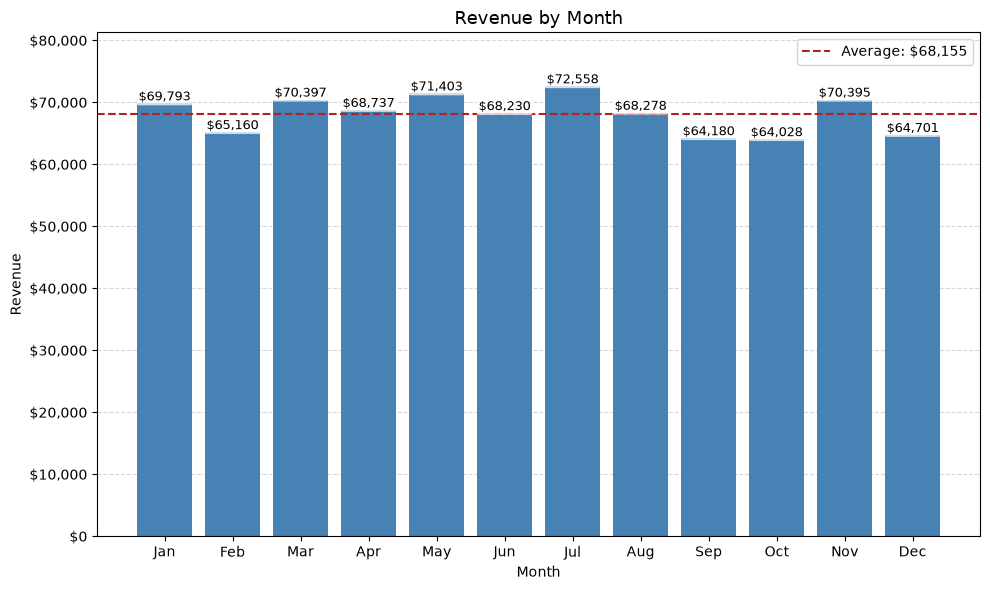

In [5]:
monthly = run("""
SELECT strftime('%Y-%m', o.order_date)           AS month,
       COUNT(DISTINCT o.order_date)              AS operating_days,
       SUM(od.quantity)                          AS total_quantity,
       ROUND(SUM(od.quantity * p.unit_price), 2) AS total_revenue
FROM orders AS o
JOIN order_details AS od ON od.order_id = o.order_id
JOIN pizzas        AS p  ON p.pizza_id  = od.pizza_id
GROUP BY month
ORDER BY month;
""")
monthly["month_label"] = pd.to_datetime(monthly["month"], format="%Y-%m").dt.strftime("%b")

bar_chart(monthly, "month_label", "total_quantity",
          "Pizzas Sold by Month", "Pizzas sold",
          "monthly_quantity.png", xlabel="Month")

bar_chart(monthly, "month_label", "total_revenue",
          "Revenue by Month", "Revenue",
          "monthly_revenue.png", money=True, xlabel="Month")

## Sales by Pizza Category

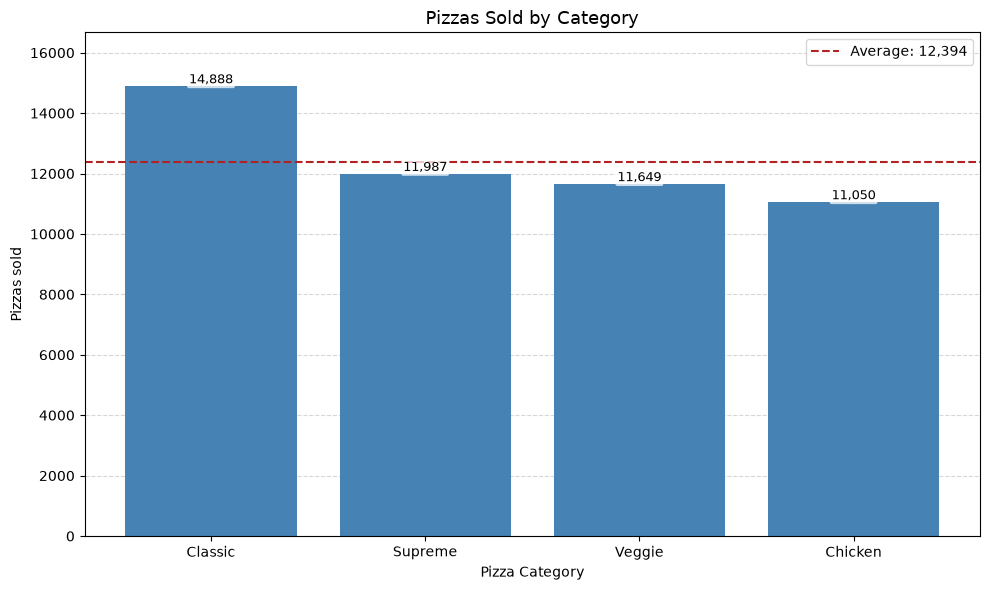

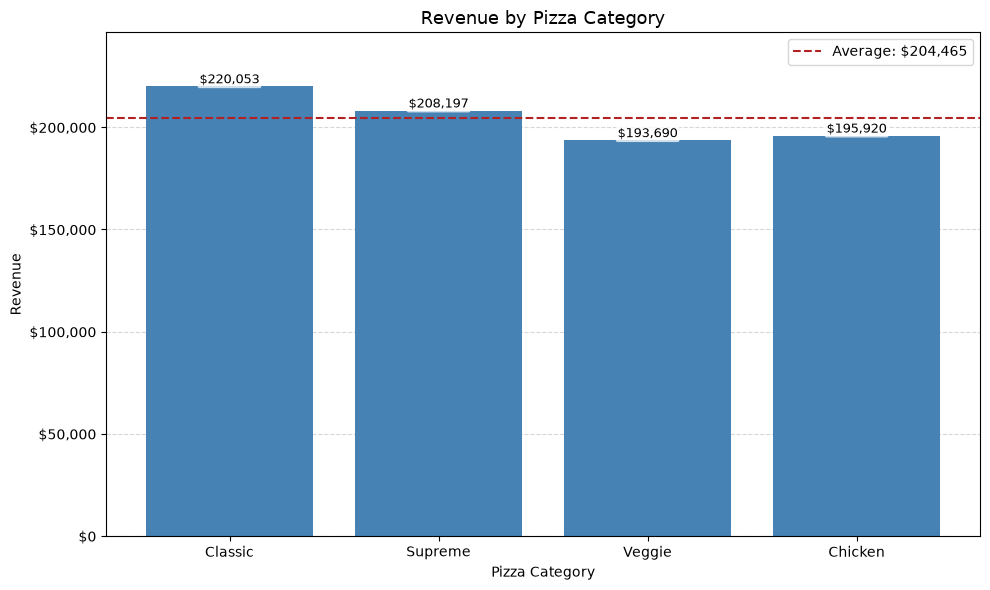

In [6]:
category = run("""
SELECT p.pizza_category,
       SUM(od.quantity)                          AS total_quantity,
       ROUND(SUM(od.quantity * p.unit_price), 2) AS total_revenue
FROM pizzas AS p
JOIN order_details AS od ON od.pizza_id = p.pizza_id
GROUP BY p.pizza_category
ORDER BY total_quantity DESC;
""")

bar_chart(category, "pizza_category", "total_quantity",
          "Pizzas Sold by Category", "Pizzas sold",
          "pizza_category_quantity.png")

bar_chart(category, "pizza_category", "total_revenue",
          "Revenue by Pizza Category", "Revenue",
          "pizza_category_revenue.png", money=True)

## Sales by Pizza Size

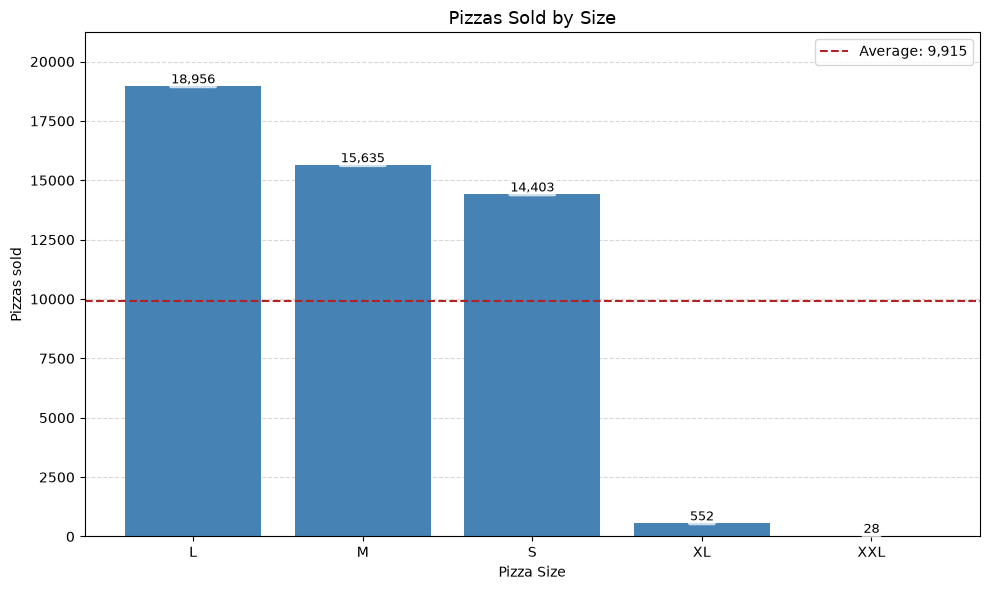

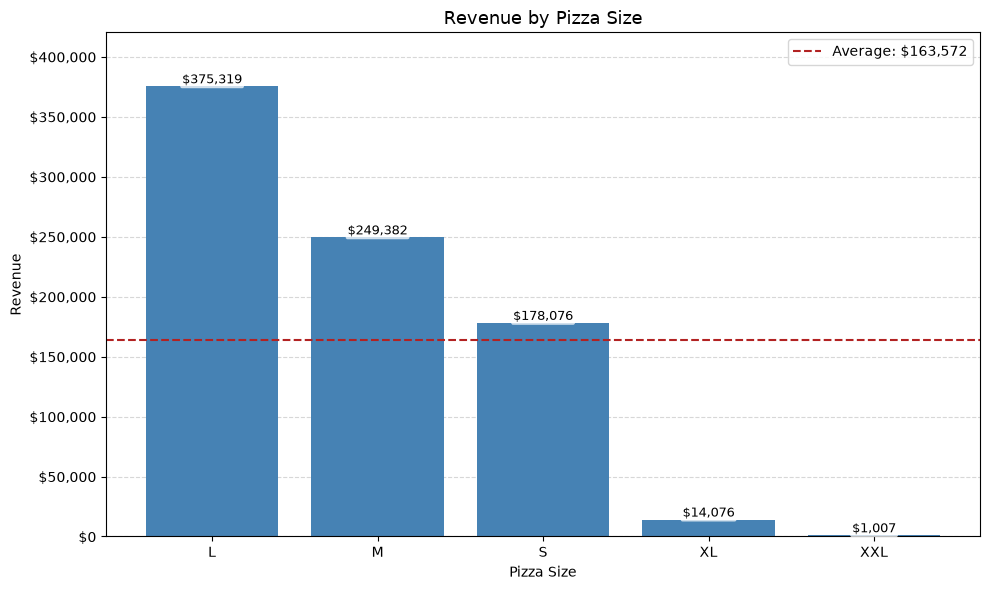

In [7]:
size = run("""
SELECT p.pizza_size,
       SUM(od.quantity)                          AS total_quantity,
       ROUND(SUM(od.quantity * p.unit_price), 2) AS total_revenue
FROM pizzas AS p
JOIN order_details AS od ON od.pizza_id = p.pizza_id
GROUP BY p.pizza_size
ORDER BY total_quantity DESC;
""")

bar_chart(size, "pizza_size", "total_quantity",
          "Pizzas Sold by Size", "Pizzas sold",
          "pizza_size_quantity.png")

bar_chart(size, "pizza_size", "total_revenue",
          "Revenue by Pizza Size", "Revenue",
          "pizza_size_revenue.png", money=True)

## The Quiet Hours, Month by Month

09:00, 10:00 and 23:00 together account for 0.18% of annual revenue. This chart checks whether
that is a steady trickle or the result of a handful of one-off orders.

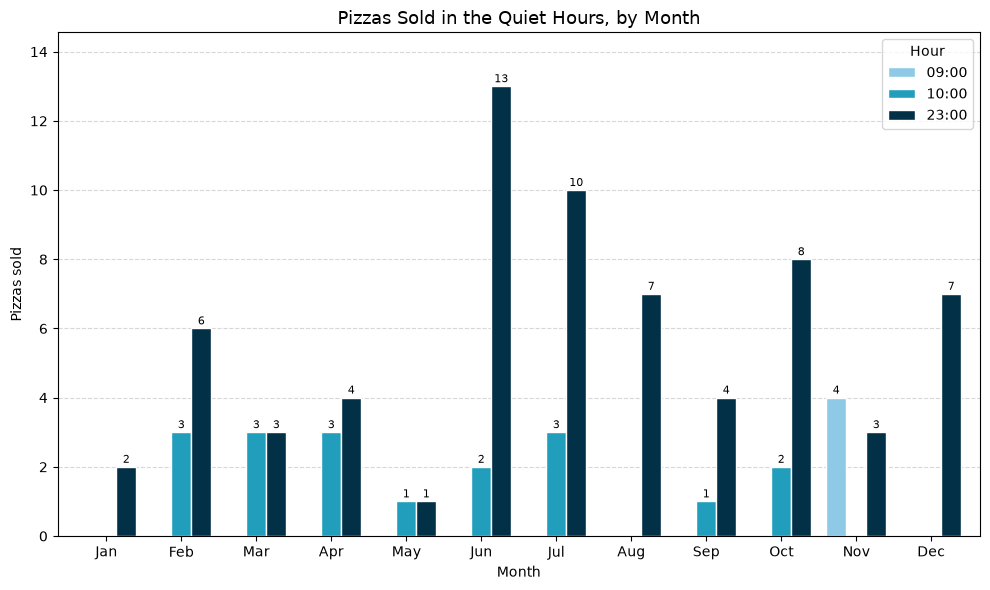

hour_of_day,09:00,10:00,23:00
month,,,
Jan,0,0,2
Feb,0,3,6
Mar,0,3,3
Apr,0,3,4
May,0,1,1
Jun,0,2,13
Jul,0,3,10
Aug,0,0,7
Sep,0,1,4


In [8]:
quiet = run("""
SELECT strftime('%Y-%m', o.order_date) AS month,
       strftime('%H:00', o.order_time) AS hour_of_day,
       SUM(od.quantity)                AS total_quantity
FROM orders AS o
JOIN order_details AS od ON od.order_id = o.order_id
WHERE strftime('%H', o.order_time) IN ('09', '10', '23')
GROUP BY month, hour_of_day
ORDER BY month, hour_of_day;
""")

pivot = (quiet.pivot(index="month", columns="hour_of_day", values="total_quantity")
              .reindex(columns=["09:00", "10:00", "23:00"])
              .fillna(0))
pivot.index = pd.to_datetime(pivot.index, format="%Y-%m").strftime("%b")

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax, width=0.8,
           color=["#8ecae6", "#219ebc", "#023047"], edgecolor="white")

for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f"{v:.0f}" if v else "", fontsize=8, padding=1)

ax.set_title("Pizzas Sold in the Quiet Hours, by Month", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Pizzas sold")
ax.legend(title="Hour")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.margins(y=0.12)
plt.setp(ax.get_xticklabels(), rotation=0)

fig.tight_layout()
fig.savefig(IMAGE_DIR / "quiet_hours_by_month.png", dpi=110)
plt.show()

pivot.astype(int)

---

In [9]:
con.close()
print(f"charts written to {IMAGE_DIR.resolve()}")

charts written to D:\GitHub_Desktop\Pizza-Sales-SQL-Project\image
